In [1]:
#setup notebook
%load_ext autoreload
%autoreload 2
%matplotlib inline
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.INFO, datefmt='%I:%M:%S')
from sdata.sclass.process_graph import ProcessGraph, get_process_graph

02:16:14 INFO:Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
02:16:14 INFO:NumExpr defaulting to 16 threads.


In [2]:
from sdata.sclass.process import sclass, processdata_class_factory, create_process_class
from sdata.sclass.process import create_process_class, create_composite_process_class, ProcessData, ProcessNode, CompositeProcess


In [3]:
"""digraph DAG {
    node [shape=box];
    CopperContainingScraps [label="Cu-haltige Schrotte"];
    PureMetal [label="Reinmetall"];
    SeparationAndWeighing [label="Trennung und Einwägung"];
    Melting [label="Schmelze"];
    ContinuousCasting [label="Strangguss"];
    OfMillingProcess [label="OF-Fräsprozess"];
    HotForming [label="Warmumformung"];
    HotRolling [label="Warmwalzen"];
    ColdForming [label="Kaltumformung"];
    ColdRolling [label="Kaltwalzen"];
    Reheating [label="Nachwärmen"];
    IntermediateAnnealing [label="Zwischenglühen"];
    Annealing [label="Anlassen"];
    ProductCharacterization [label="Charakterisierung des Produkts"];
    DigitalProductPassportCreation [label="Erstellung des digitalen Produktpasses (DPP)"];
    IncomingInspection [label="Eingangsprüfung"];
    ContactManufacturing [label="Kontaktfertigung"];
    Galvanizing [label="Galvanik"];
    Assembly [label="Montage"];
    ComponentTesting [label="Bauteilprüfung"];
    PlasticComponentSustainability [label="Kunststoffanteil – Nachhaltigkeit"];
    Calibration [label="Kalibrierung"];
    Distribution [label="Distribution"];
    ProductUse [label="Produkteinsatz"];
    EndOfLife [label="EoL"];

    CopperContainingScraps -> SeparationAndWeighing;
    PureMetal -> SeparationAndWeighing;
    SeparationAndWeighing -> Melting;
    Melting -> ContinuousCasting;
    ContinuousCasting -> OfMillingProcess;
    OfMillingProcess -> HotForming;
    HotForming -> HotRolling;
    HotRolling -> ColdForming;
    ColdForming -> ColdRolling;
    ColdRolling -> Reheating;
    Reheating -> IntermediateAnnealing;
    IntermediateAnnealing -> Annealing;
    Annealing -> ProductCharacterization;
    ProductCharacterization -> DigitalProductPassportCreation;
    DigitalProductPassportCreation -> IncomingInspection;
    IncomingInspection -> ContactManufacturing;
    ContactManufacturing -> Galvanizing;
    Galvanizing -> Assembly;
    Assembly -> ComponentTesting;
    ComponentTesting -> DigitalProductPassportCreation; // Second DPP
    PlasticComponentSustainability -> Assembly; // Branch
    Calibration -> Distribution;
    Distribution -> ProductUse;
    ProductUse -> EndOfLife;
}
"""

'digraph DAG {\n    node [shape=box];\n    CopperContainingScraps [label="Cu-haltige Schrotte"];\n    PureMetal [label="Reinmetall"];\n    SeparationAndWeighing [label="Trennung und Einwägung"];\n    Melting [label="Schmelze"];\n    ContinuousCasting [label="Strangguss"];\n    OfMillingProcess [label="OF-Fräsprozess"];\n    HotForming [label="Warmumformung"];\n    HotRolling [label="Warmwalzen"];\n    ColdForming [label="Kaltumformung"];\n    ColdRolling [label="Kaltwalzen"];\n    Reheating [label="Nachwärmen"];\n    IntermediateAnnealing [label="Zwischenglühen"];\n    Annealing [label="Anlassen"];\n    ProductCharacterization [label="Charakterisierung des Produkts"];\n    DigitalProductPassportCreation [label="Erstellung des digitalen Produktpasses (DPP)"];\n    IncomingInspection [label="Eingangsprüfung"];\n    ContactManufacturing [label="Kontaktfertigung"];\n    Galvanizing [label="Galvanik"];\n    Assembly [label="Montage"];\n    ComponentTesting [label="Bauteilprüfung"];\n    Pla

In [4]:
copper_processes = {
    "SeparationAndWeighingProcess": {
        "input_data": ["CopperContainingScraps", "PureMetal"],
        "process_name": "SeparationAndWeighingProcess",
        "output_data": ["SeparatedWeighedCopperMaterials"]
    },
    "MeltingProcess": {
        "input_data": ["SeparatedWeighedCopperMaterials"],
        "process_name": "MeltingProcess",
        "output_data": ["MoltenCopperAlloy"]
    },
    "ContinuousCastingProcess": {
        "input_data": ["MoltenCopperAlloy"],
        "process_name": "ContinuousCastingProcess",
        "output_data": ["CastCopperBars"]
    },
    "OfMillingProcess": {
        "input_data": ["CastCopperBars"],
        "process_name": "OfMillingProcess",
        "output_data": ["MilledOxygenFreeCopper"]
    },
    "HotFormingProcess": {
        "input_data": ["MilledOxygenFreeCopper"],
        "process_name": "HotFormingProcess",
        "output_data": ["HotFormedCopperProfiles"]
    },
    "HotRollingProcess": {
        "input_data": ["HotFormedCopperProfiles"],
        "process_name": "HotRollingProcess",
        "output_data": ["HotRolledCopperSheets"]
    },
    "ColdFormingProcess": {
        "input_data": ["HotRolledCopperSheets"],
        "process_name": "ColdFormingProcess",
        "output_data": ["ColdFormedCopperComponents"]
    },
    "ColdRollingProcess": {
        "input_data": ["ColdFormedCopperComponents"],
        "process_name": "ColdRollingProcess",
        "output_data": ["ColdRolledCopperStrips"]
    },
    "ReheatingProcess": {
        "input_data": ["ColdRolledCopperStrips"],
        "process_name": "ReheatingProcess",
        "output_data": ["ReheatedCopperStrips"]
    },
    "IntermediateAnnealingProcess": {
        "input_data": ["ReheatedCopperStrips"],
        "process_name": "IntermediateAnnealingProcess",
        "output_data": ["IntermediateAnnealedCopperStrips"]
    },
    "AnnealingProcess": {
        "input_data": ["IntermediateAnnealedCopperStrips"],
        "process_name": "AnnealingProcess",
        "output_data": ["AnnealedCopperStrips"]
    },
    "ProductCharacterizationProcess": {
        "input_data": ["AnnealedCopperStrips"],
        "process_name": "ProductCharacterizationProcess",
        "output_data": ["CharacterizedCopperSemifinished"]
    },
    "DigitalProductPassportCreationProcess": {
        "input_data": ["CharacterizedCopperSemifinished"],
        "process_name": "DigitalProductPassportCreationProcess",
        "output_data": ["CopperSemifinishedWithDpp"]
    },
    "IncomingInspectionProcess": {
        "input_data": ["CopperSemifinishedWithDpp"],
        "process_name": "IncomingInspectionProcess",
        "output_data": ["InspectedCopperSemifinished"]
    },
    "ContactManufacturingProcess": {
        "input_data": ["InspectedCopperSemifinished"],
        "process_name": "ContactManufacturingProcess",
        "output_data": ["ManufacturedCopperContacts"]
    },
    "GalvanizingProcess": {
        "input_data": ["ManufacturedCopperContacts"],
        "process_name": "GalvanizingProcess",
        "output_data": ["GalvanizedCopperContacts"]
    },
    "AssemblyProcess": {
        "input_data": ["GalvanizedCopperContacts", "SustainablePlasticComponents"],
        "process_name": "AssemblyProcess",
        "output_data": ["AssembledCopperConnectorWithHousing"]
    },
    "ComponentTestingProcess": {
        "input_data": ["AssembledCopperConnectorWithHousing"],
        "process_name": "ComponentTestingProcess",
        "output_data": ["TestedCopperConnector"]
    },
    "DigitalProductPassportUpdateProcess": {
        "input_data": ["TestedCopperConnector"],
        "process_name": "DigitalProductPassportUpdateProcess",
        "output_data": ["FinalCopperConnectorWithDpp"]
    },
    "CalibrationProcess": {
        "input_data": ["FinalCopperConnectorWithDpp"],
        "process_name": "CalibrationProcess",
        "output_data": ["CalibratedCopperConnector"]
    },
    "DistributionProcess": {
        "input_data": ["CalibratedCopperConnector"],
        "process_name": "DistributionProcess",
        "output_data": ["DistributedCopperConnector"]
    },
    "ProductUseProcess": {
        "input_data": ["DistributedCopperConnector"],
        "process_name": "ProductUseProcess",
        "output_data": ["UsedCopperConnector"]
    },
    "EndOfLifeProcess": {
        "input_data": ["UsedCopperConnector"],
        "process_name": "EndOfLifeProcess",
        "output_data": ["EolCopperMaterials"]
    }
}

In [5]:
process_dict = copper_processes["GalvanizingProcess"]
process_dict

{'input_data': ['ManufacturedCopperContacts'],
 'process_name': 'GalvanizingProcess',
 'output_data': ['GalvanizedCopperContacts']}

In [6]:
{i:sclass(i) for i in process_dict["input_data"]}

{'ManufacturedCopperContacts': sdata.sclass.process.ManufacturedCopperContacts}

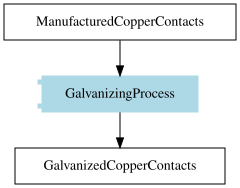

In [7]:
p = create_process_class(process_dict["process_name"], 
                              {i:sclass(i) for i in process_dict["input_data"]}, 
                              {o:sclass(o) for o in process_dict["output_data"]})
g =get_process_graph([p])
g

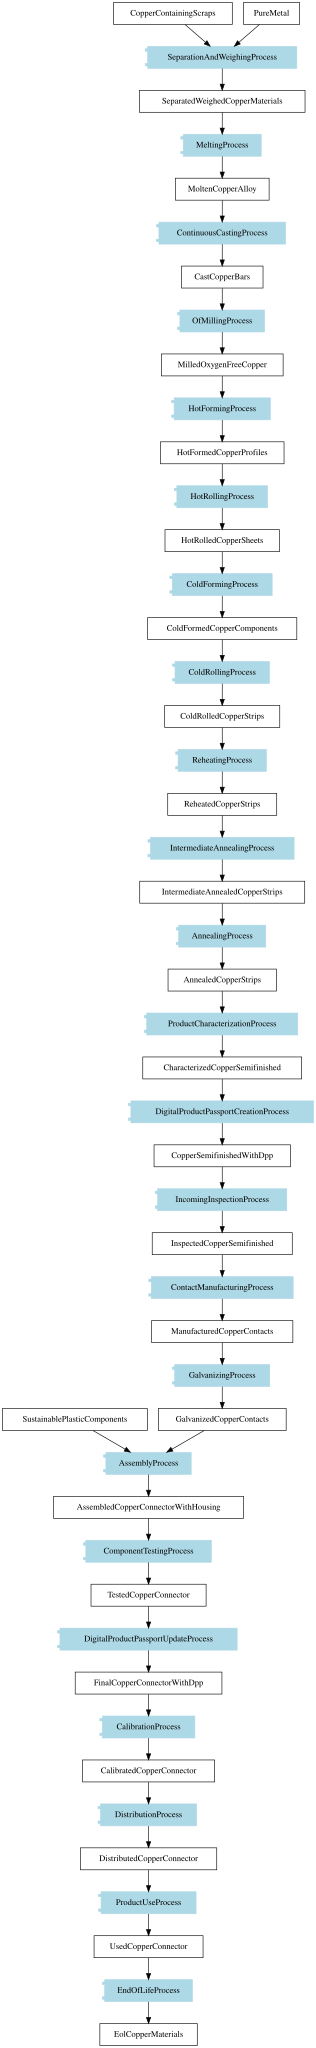

In [151]:
from sdata.sclass.process_graph import ProcessGraph
from IPython.display import display, SVG

copper_processes_dict = {}

g = ProcessGraph()
for process_dict in copper_processes.values():
    p = create_process_class(process_dict["process_name"], 
                              {i:sclass(i) for i in process_dict["input_data"]}, 
                              {o:sclass(o) for o in process_dict["output_data"]})
    g.add_process(p)
    copper_processes_dict[process_dict["process_name"]] = p
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
dot_graph.render(f"/tmp/lifecycle_processes/all_processes", format="png")
dot_graph

In [9]:
dot_graph.save("copper_processes.gv")

'copper_processes.gv'

In [10]:
dot_graph.render("copper_processes")

'copper_processes.pdf'

In [11]:
print(dot_graph.source)

digraph CombinedProcess {
	graph [rankdir=TD]
	GalvanizedCopperContacts [label=GalvanizedCopperContacts shape=box]
	CopperContainingScraps [label=CopperContainingScraps shape=box]
	DistributedCopperConnector [label=DistributedCopperConnector shape=box]
	CharacterizedCopperSemifinished [label=CharacterizedCopperSemifinished shape=box]
	CalibratedCopperConnector [label=CalibratedCopperConnector shape=box]
	ColdFormedCopperComponents [label=ColdFormedCopperComponents shape=box]
	ManufacturedCopperContacts [label=ManufacturedCopperContacts shape=box]
	SustainablePlasticComponents [label=SustainablePlasticComponents shape=box]
	MilledOxygenFreeCopper [label=MilledOxygenFreeCopper shape=box]
	ColdRolledCopperStrips [label=ColdRolledCopperStrips shape=box]
	EolCopperMaterials [label=EolCopperMaterials shape=box]
	SeparatedWeighedCopperMaterials [label=SeparatedWeighedCopperMaterials shape=box]
	InspectedCopperSemifinished [label=InspectedCopperSemifinished shape=box]
	AnnealedCopperStrips [la

In [12]:
gvs = """digraph CombinedProcess {
	graph [rankdir=TD]
	subgraph cluster_RawMaterialPreparation {
		label="Rohmaterialvorbereitung (Raw Material Preparation)"
		CopperContainingScraps [label=CopperContainingScraps shape=box]
		PureMetal [label=PureMetal shape=box]
		SeparationAndWeighingProcess [label=SeparationAndWeighingProcess color=lightblue shape=component style=filled]
		SeparatedWeighedCopperMaterials [label=SeparatedWeighedCopperMaterials shape=box]
	}
	subgraph cluster_MeltingAndCasting {
		label="Schmelzen und Gießen (Melting and Casting)"
		MeltingProcess [label=MeltingProcess color=lightblue shape=component style=filled]
		MoltenCopperAlloy [label=MoltenCopperAlloy shape=box]
		ContinuousCastingProcess [label=ContinuousCastingProcess color=lightblue shape=component style=filled]
		CastCopperBars [label=CastCopperBars shape=box]
	}
	subgraph cluster_FormingAndRolling {
		label="Umformung und Walzen (Forming and Rolling)"
		OfMillingProcess [label=OfMillingProcess color=lightblue shape=component style=filled]
		MilledOxygenFreeCopper [label=MilledOxygenFreeCopper shape=box]
		HotFormingProcess [label=HotFormingProcess color=lightblue shape=component style=filled]
		HotFormedCopperProfiles [label=HotFormedCopperProfiles shape=box]
		HotRollingProcess [label=HotRollingProcess color=lightblue shape=component style=filled]
		HotRolledCopperSheets [label=HotRolledCopperSheets shape=box]
		ColdFormingProcess [label=ColdFormingProcess color=lightblue shape=component style=filled]
		ColdFormedCopperComponents [label=ColdFormedCopperComponents shape=box]
		ColdRollingProcess [label=ColdRollingProcess color=lightblue shape=component style=filled]
		ColdRolledCopperStrips [label=ColdRolledCopperStrips shape=box]
	}
	subgraph cluster_HeatTreatment {
		label="Wärmebehandlung (Heat Treatment)"
		ReheatingProcess [label=ReheatingProcess color=lightblue shape=component style=filled]
		ReheatedCopperStrips [label=ReheatedCopperStrips shape=box]
		IntermediateAnnealingProcess [label=IntermediateAnnealingProcess color=lightblue shape=component style=filled]
		IntermediateAnnealedCopperStrips [label=IntermediateAnnealedCopperStrips shape=box]
		AnnealingProcess [label=AnnealingProcess color=lightblue shape=component style=filled]
		AnnealedCopperStrips [label=AnnealedCopperStrips shape=box]
	}
	subgraph cluster_SemifinishedCharacterizationAndDpp {
		label="Halbzeugherstellung - Charakterisierung und DPP (Semifinished Characterization and DPP)"
		ProductCharacterizationProcess [label=ProductCharacterizationProcess color=lightblue shape=component style=filled]
		CharacterizedCopperSemifinished [label=CharacterizedCopperSemifinished shape=box]
		DigitalProductPassportCreationProcess [label=DigitalProductPassportCreationProcess color=lightblue shape=component style=filled]
		CopperSemifinishedWithDpp [label=CopperSemifinishedWithDpp shape=box]
	}
	subgraph cluster_FinalProductManufacturing {
		label="Endproduktfertigung (Final Product Manufacturing)"
		IncomingInspectionProcess [label=IncomingInspectionProcess color=lightblue shape=component style=filled]
		InspectedCopperSemifinished [label=InspectedCopperSemifinished shape=box]
		ContactManufacturingProcess [label=ContactManufacturingProcess color=lightblue shape=component style=filled]
		ManufacturedCopperContacts [label=ManufacturedCopperContacts shape=box]
		GalvanizingProcess [label=GalvanizingProcess color=lightblue shape=component style=filled]
		GalvanizedCopperContacts [label=GalvanizedCopperContacts shape=box]
		SustainablePlasticComponents [label=SustainablePlasticComponents shape=box]
		AssemblyProcess [label=AssemblyProcess color=lightblue shape=component style=filled]
		AssembledCopperConnectorWithHousing [label=AssembledCopperConnectorWithHousing shape=box]
	}
	subgraph cluster_TestingAndDppUpdate {
		label="Prüfung und DPP-Update (Testing and DPP Update)"
		ComponentTestingProcess [label=ComponentTestingProcess color=lightblue shape=component style=filled]
		TestedCopperConnector [label=TestedCopperConnector shape=box]
		DigitalProductPassportUpdateProcess [label=DigitalProductPassportUpdateProcess color=lightblue shape=component style=filled]
		FinalCopperConnectorWithDpp [label=FinalCopperConnectorWithDpp shape=box]
	}
	subgraph cluster_CalibrationAndDistribution {
		label="Kalibrierung und Distribution (Calibration and Distribution)"
		CalibrationProcess [label=CalibrationProcess color=lightblue shape=component style=filled]
		CalibratedCopperConnector [label=CalibratedCopperConnector shape=box]
		DistributionProcess [label=DistributionProcess color=lightblue shape=component style=filled]
		DistributedCopperConnector [label=DistributedCopperConnector shape=box]
	}
	subgraph cluster_UsageAndEol {
		label="Nutzung und EoL (Usage and EoL)"
		ProductUseProcess [label=ProductUseProcess color=lightblue shape=component style=filled]
		UsedCopperConnector [label=UsedCopperConnector shape=box]
		EndOfLifeProcess [label=EndOfLifeProcess color=lightblue shape=component style=filled]
		EolCopperMaterials [label=EolCopperMaterials shape=box]
	}
	CopperContainingScraps -> SeparationAndWeighingProcess
	PureMetal -> SeparationAndWeighingProcess
	SeparationAndWeighingProcess -> SeparatedWeighedCopperMaterials
	SeparatedWeighedCopperMaterials -> MeltingProcess
	MeltingProcess -> MoltenCopperAlloy
	MoltenCopperAlloy -> ContinuousCastingProcess
	ContinuousCastingProcess -> CastCopperBars
	CastCopperBars -> OfMillingProcess
	OfMillingProcess -> MilledOxygenFreeCopper
	MilledOxygenFreeCopper -> HotFormingProcess
	HotFormingProcess -> HotFormedCopperProfiles
	HotFormedCopperProfiles -> HotRollingProcess
	HotRollingProcess -> HotRolledCopperSheets
	HotRolledCopperSheets -> ColdFormingProcess
	ColdFormingProcess -> ColdFormedCopperComponents
	ColdFormedCopperComponents -> ColdRollingProcess
	ColdRollingProcess -> ColdRolledCopperStrips
	ColdRolledCopperStrips -> ReheatingProcess
	ReheatingProcess -> ReheatedCopperStrips
	ReheatedCopperStrips -> IntermediateAnnealingProcess
	IntermediateAnnealingProcess -> IntermediateAnnealedCopperStrips
	IntermediateAnnealedCopperStrips -> AnnealingProcess
	AnnealingProcess -> AnnealedCopperStrips
	AnnealedCopperStrips -> ProductCharacterizationProcess
	ProductCharacterizationProcess -> CharacterizedCopperSemifinished
	CharacterizedCopperSemifinished -> DigitalProductPassportCreationProcess
	DigitalProductPassportCreationProcess -> CopperSemifinishedWithDpp
	CopperSemifinishedWithDpp -> IncomingInspectionProcess
	IncomingInspectionProcess -> InspectedCopperSemifinished
	InspectedCopperSemifinished -> ContactManufacturingProcess
	ContactManufacturingProcess -> ManufacturedCopperContacts
	ManufacturedCopperContacts -> GalvanizingProcess
	GalvanizingProcess -> GalvanizedCopperContacts
	GalvanizedCopperContacts -> AssemblyProcess
	SustainablePlasticComponents -> AssemblyProcess
	AssemblyProcess -> AssembledCopperConnectorWithHousing
	AssembledCopperConnectorWithHousing -> ComponentTestingProcess
	ComponentTestingProcess -> TestedCopperConnector
	TestedCopperConnector -> DigitalProductPassportUpdateProcess
	DigitalProductPassportUpdateProcess -> FinalCopperConnectorWithDpp
	FinalCopperConnectorWithDpp -> CalibrationProcess
	CalibrationProcess -> CalibratedCopperConnector
	CalibratedCopperConnector -> DistributionProcess
	DistributionProcess -> DistributedCopperConnector
	DistributedCopperConnector -> ProductUseProcess
	ProductUseProcess -> UsedCopperConnector
	UsedCopperConnector -> EndOfLifeProcess
	EndOfLifeProcess -> EolCopperMaterials
}"""

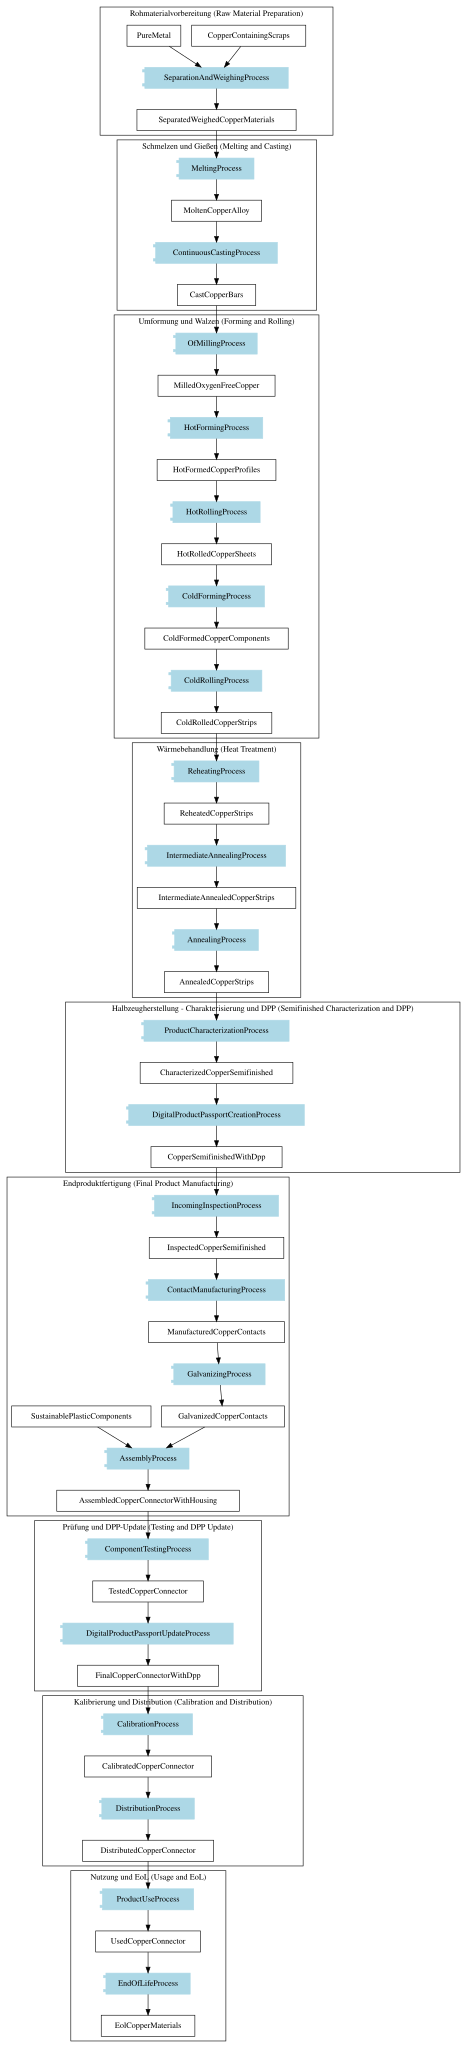

In [13]:
from graphviz import Source
s = Source(gvs, format='svg')  # Use 'svg' for interactive rendering or 'png' for static image
s

In [14]:
grouped_processes_dict = {
    'RawMaterialPreparation': {
        'process_name': 'RawMaterialPreparation',
        'label': 'Rohmaterialvorbereitung (Raw Material Preparation)',
        'processes': ['SeparationAndWeighingProcess']
    },
    'MeltingAndCasting': {
        'process_name': 'MeltingAndCasting',
        'label': 'Schmelzen und Gießen (Melting and Casting)',
        'processes': ['MeltingProcess', 'ContinuousCastingProcess']
    },
    'FormingAndRolling': {
        'process_name': 'FormingAndRolling',
        'label': 'Umformung und Walzen (Forming and Rolling)',
        'processes': ['OfMillingProcess', 'HotFormingProcess', 'HotRollingProcess', 'ColdFormingProcess', 'ColdRollingProcess']
    },
    'HeatTreatment': {
        'process_name': 'HeatTreatment',
        'label': 'Wärmebehandlung (Heat Treatment)',
        'processes': ['ReheatingProcess', 'IntermediateAnnealingProcess', 'AnnealingProcess']
    },
    'SemifinishedCharacterizationAndDpp': {
        'process_name': 'SemifinishedCharacterizationAndDpp',
        'label': 'Halbzeugherstellung - Charakterisierung und DPP (Semifinished Characterization and DPP)',
        'processes': ['ProductCharacterizationProcess', 'DigitalProductPassportCreationProcess']
    },
    'FinalProductManufacturing': {
        'process_name': 'FinalProductManufacturing',
        'label': 'Endproduktfertigung (Final Product Manufacturing)',
        'processes': ['IncomingInspectionProcess', 'ContactManufacturingProcess', 'GalvanizingProcess', 'AssemblyProcess']
    },
    'TestingAndDppUpdate': {
        'process_name': 'TestingAndDppUpdate',
        'label': 'Prüfung und DPP-Update (Testing and DPP Update)',
        'processes': ['ComponentTestingProcess', 'DigitalProductPassportUpdateProcess']
    },
    'CalibrationAndDistribution': {
        'process_name': 'CalibrationAndDistribution',
        'label': 'Kalibrierung und Distribution (Calibration and Distribution)',
        'processes': ['CalibrationProcess', 'DistributionProcess']
    },
    'UsageAndEol': {
        'process_name': 'UsageAndEol',
        'label': 'Nutzung und EoL (Usage and EoL)',
        'processes': ['ProductUseProcess', 'EndOfLifeProcess']
    }
}
grouped_processes_dict

{'RawMaterialPreparation': {'process_name': 'RawMaterialPreparation',
  'label': 'Rohmaterialvorbereitung (Raw Material Preparation)',
  'processes': ['SeparationAndWeighingProcess']},
 'MeltingAndCasting': {'process_name': 'MeltingAndCasting',
  'label': 'Schmelzen und Gießen (Melting and Casting)',
  'processes': ['MeltingProcess', 'ContinuousCastingProcess']},
 'FormingAndRolling': {'process_name': 'FormingAndRolling',
  'label': 'Umformung und Walzen (Forming and Rolling)',
  'processes': ['OfMillingProcess',
   'HotFormingProcess',
   'HotRollingProcess',
   'ColdFormingProcess',
   'ColdRollingProcess']},
 'HeatTreatment': {'process_name': 'HeatTreatment',
  'label': 'Wärmebehandlung (Heat Treatment)',
  'processes': ['ReheatingProcess',
   'IntermediateAnnealingProcess',
   'AnnealingProcess']},
 'SemifinishedCharacterizationAndDpp': {'process_name': 'SemifinishedCharacterizationAndDpp',
  'label': 'Halbzeugherstellung - Charakterisierung und DPP (Semifinished Characterization a

In [119]:
grouped_processes_dict = {
    'MeltingAndCasting': {
        'process_name': 'MeltingAndCasting',
        'label': 'Schmelzen und Gießen (Melting and Casting)',
        'processes': ['SeparationAndWeighingProcess', 'MeltingProcess', 'ContinuousCastingProcess']
    },
    'FormingAndRolling': {
        'process_name': 'FormingAndRolling',
        'label': 'Umformung und Walzen (Forming and Rolling)',
        'processes': ['OfMillingProcess', 'HotFormingProcess', 'HotRollingProcess', 'ColdFormingProcess', 'ColdRollingProcess']
    },
    'HeatTreatment': {
        'process_name': 'HeatTreatment',
        'label': 'Wärmebehandlung (Heat Treatment)',
        'processes': ['ReheatingProcess', 'IntermediateAnnealingProcess', 'AnnealingProcess']
    },
    'SemifinishedCharacterizationAndDpp': {
        'process_name': 'SemifinishedCharacterizationAndDpp',
        'label': 'Halbzeugherstellung - Charakterisierung und DPP (Semifinished Characterization and DPP)',
        'processes': ['ProductCharacterizationProcess', 'DigitalProductPassportCreationProcess', 
                      'IncomingInspectionProcess', 'ContactManufacturingProcess', 'GalvanizingProcess', ]
    },
    'FinalProductManufacturing': {
        'process_name': 'FinalProductManufacturing',
        'label': 'Endproduktfertigung (Final Product Manufacturing)',
        'processes': ['AssemblyProcess', 'ComponentTestingProcess', 'DigitalProductPassportUpdateProcess']
    },
#    'TestingAndDppUpdate': {
#        'process_name': 'TestingAndDppUpdate',
#        'label': 'Prüfung und DPP-Update (Testing and DPP Update)',
#        'processes': ['ComponentTestingProcess', 'DigitalProductPassportUpdateProcess']
#    },
    'CalibrationAndDistribution': {
        'process_name': 'CalibrationAndDistribution',
        'label': 'Kalibrierung und Distribution (Calibration and Distribution)',
        'processes': ['CalibrationProcess', 'DistributionProcess']
    },
    'UsageAndEol': {
        'process_name': 'UsageAndEol',
        'label': 'Nutzung und EoL (Usage and EoL)',
        'processes': ['ProductUseProcess', 'EndOfLifeProcess']
    }
}
grouped_processes_dict

{'MeltingAndCasting': {'process_name': 'MeltingAndCasting',
  'label': 'Schmelzen und Gießen (Melting and Casting)',
  'processes': ['SeparationAndWeighingProcess',
   'MeltingProcess',
   'ContinuousCastingProcess']},
 'FormingAndRolling': {'process_name': 'FormingAndRolling',
  'label': 'Umformung und Walzen (Forming and Rolling)',
  'processes': ['OfMillingProcess',
   'HotFormingProcess',
   'HotRollingProcess',
   'ColdFormingProcess',
   'ColdRollingProcess']},
 'HeatTreatment': {'process_name': 'HeatTreatment',
  'label': 'Wärmebehandlung (Heat Treatment)',
  'processes': ['ReheatingProcess',
   'IntermediateAnnealingProcess',
   'AnnealingProcess']},
 'SemifinishedCharacterizationAndDpp': {'process_name': 'SemifinishedCharacterizationAndDpp',
  'label': 'Halbzeugherstellung - Charakterisierung und DPP (Semifinished Characterization and DPP)',
  'processes': ['ProductCharacterizationProcess',
   'DigitalProductPassportCreationProcess',
   'IncomingInspectionProcess',
   'Contact

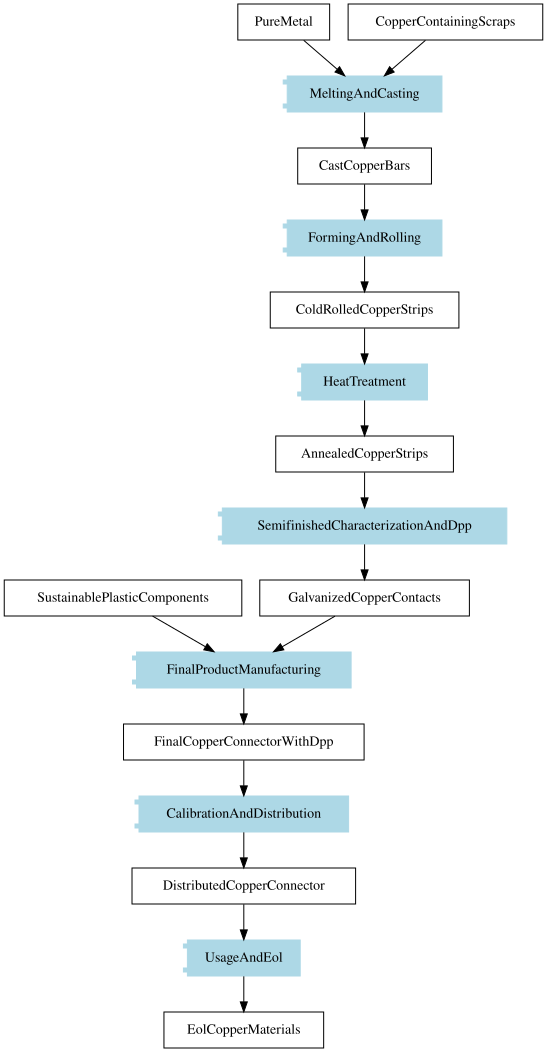

In [148]:
grouped_processes = {}
g = ProcessGraph()
for process_dict in grouped_processes_dict.values():
    subprocesses = [copper_processes_dict[pname] for pname in process_dict["processes"]]
    name = process_dict["process_name"]
#    print(name, subprocesses)
    p = create_composite_process_class(name, subprocesses)
    g.add_process(p)
#    ProcessNode(process_dict["process_name"], processes=[copper_processes_dict[pname] for pname in process_dict["processes"]])
    grouped_processes[p.__name__] = p
dot_graph = g.to_graphviz(name="GroupedProcess", rankdir="TD", collapsed=True)
dot_graph.render(f"/tmp/lifecycle_processes/grouped_processes", format="png")
dot_graph

In [121]:
grouped_processes

{'MeltingAndCasting': sdata.sclass.process.MeltingAndCasting,
 'FormingAndRolling': sdata.sclass.process.FormingAndRolling,
 'HeatTreatment': sdata.sclass.process.HeatTreatment,
 'SemifinishedCharacterizationAndDpp': sdata.sclass.process.SemifinishedCharacterizationAndDpp,
 'FinalProductManufacturing': sdata.sclass.process.FinalProductManufacturing,
 'CalibrationAndDistribution': sdata.sclass.process.CalibrationAndDistribution,
 'UsageAndEol': sdata.sclass.process.UsageAndEol}

In [122]:
for pg in grouped_processes.values():
    g = ProcessGraph()
    [g.add_process(p) for p in pg.processes]
    dot_graph = g.to_graphviz(name="GroupedProcess", rankdir="TD", collapsed=True)
    dot_graph.render(f"/tmp/{pg.__name__}", format="png")
    print(f"/tmp/{pg.__name__}")

/tmp/MeltingAndCasting
/tmp/FormingAndRolling
/tmp/HeatTreatment
/tmp/SemifinishedCharacterizationAndDpp
/tmp/FinalProductManufacturing
/tmp/CalibrationAndDistribution
/tmp/UsageAndEol


In [150]:
grouped_processes.keys()

dict_keys(['MeltingAndCasting', 'FormingAndRolling', 'HeatTreatment', 'SemifinishedCharacterizationAndDpp', 'FinalProductManufacturing', 'CalibrationAndDistribution', 'UsageAndEol'])

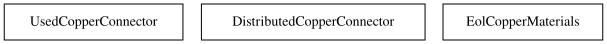

In [123]:
dot_graph = g.to_graphviz_cluster(name="SemifinishedCharacterizationAndDpp")
dot_graph

In [124]:
g.data_nodes

{'DistributedCopperConnector', 'EolCopperMaterials', 'UsedCopperConnector'}

In [125]:
g.input_classes

{'UsedCopperConnector': sdata.sclass.process.UsedCopperConnector}

In [126]:
g.output_classes

{'EolCopperMaterials': sdata.sclass.process.EolCopperMaterials}

In [127]:
g.update_class_map()

In [128]:
dot_graph.render(f"/tmp/{p.__name__}", format="png")

'/tmp/UsageAndEol.png'

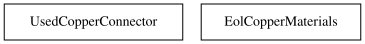

In [129]:
dot_graph = g.to_graphviz_cluster(name="SemifinishedCharacterizationAndDpp")
dot_graph

In [130]:
print(dot_graph.source)

digraph SemifinishedCharacterizationAndDpp {
	graph [rankdir=TD]
	UsedCopperConnector [label=UsedCopperConnector shape=box]
	EolCopperMaterials [label=EolCopperMaterials shape=box]
	subgraph cluster_use_eol {
		color=black fillcolor="#efffff" label=ProcessGraph labeljust=l labelloc=t penwidth=1.5 peripheries=1 style=filled
	}
}



In [131]:
import graphviz

In [132]:
p.input_classes, p.output_classes

({'DistributedCopperConnector': sdata.sclass.process.DistributedCopperConnector},
 {'EolCopperMaterials': sdata.sclass.process.EolCopperMaterials})

In [133]:
pg = grouped_processes["MeltingAndCasting"]
pg

sdata.sclass.process.MeltingAndCasting

In [134]:
pg.input_classes

{'CopperContainingScraps': sdata.sclass.process.CopperContainingScraps,
 'PureMetal': sdata.sclass.process.PureMetal}

In [135]:
pg.output_classes

{'CastCopperBars': sdata.sclass.process.CastCopperBars}

In [136]:
pg.processes

[sdata.sclass.process.SeparationAndWeighingProcess,
 sdata.sclass.process.MeltingProcess,
 sdata.sclass.process.ContinuousCastingProcess]

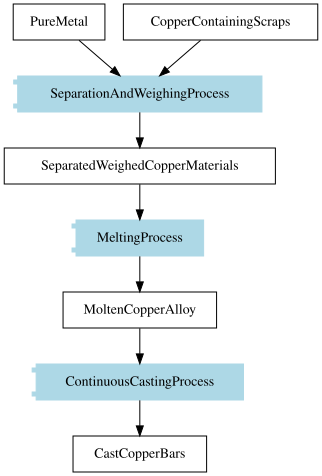

In [137]:
g = ProcessGraph()
for p in pg.processes:
    g.add_process(p)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
dot_graph

<class 'sdata.sclass.process.SeparationAndWeighingProcess'>
<class 'sdata.sclass.process.MeltingProcess'>
<class 'sdata.sclass.process.ContinuousCastingProcess'>


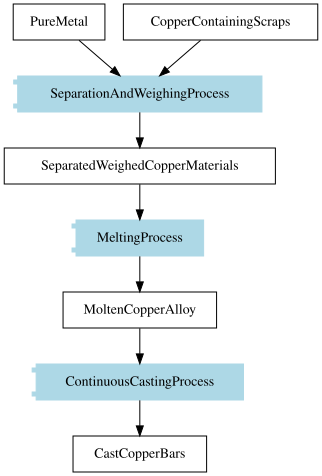

In [138]:
pg = grouped_processes["MeltingAndCasting"]
pgv = ProcessGraph()
pgv.add_process(pg)

sg = ProcessGraph()
for p in pg.processes:
    print(p)
    sg.add_process(p)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
dot_graph

In [139]:
pgv.processes[0].processes

[sdata.sclass.process.SeparationAndWeighingProcess,
 sdata.sclass.process.MeltingProcess,
 sdata.sclass.process.ContinuousCastingProcess]

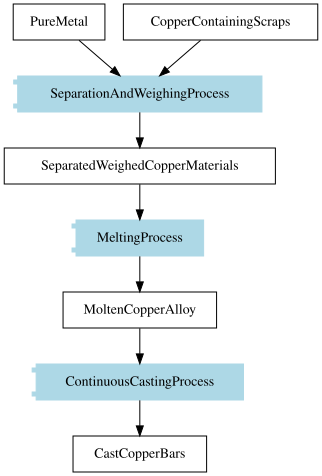

In [140]:
sg.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

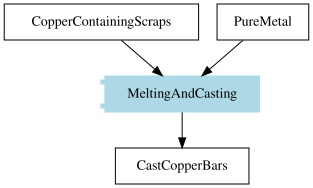

In [141]:
pg = grouped_processes["MeltingAndCasting"]
pgv = ProcessGraph(name=pg.__name__)
pgv.add_process(pg)
pgv.to_graphviz()

In [142]:
pgv.processes

[sdata.sclass.process.MeltingAndCasting]

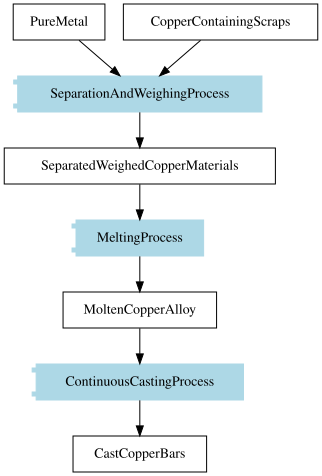

In [143]:
pgv.get_subprocess_graph().to_graphviz()

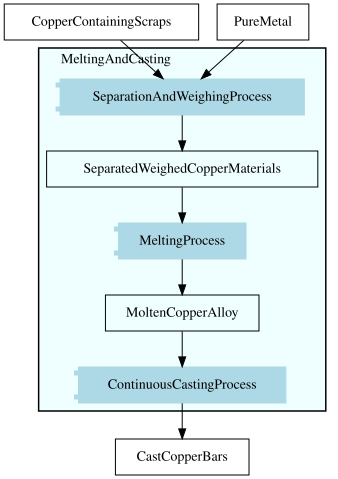

In [144]:
pgv.to_graphviz_cluster()

In [147]:
for pg in grouped_processes.values():
    pgv = ProcessGraph(name=pg.__name__)
    pgv.add_process(pg)
    dot_graph = pgv.to_graphviz_cluster(name=pg.__name__, rankdir="TD", collapsed=True)
    dot_graph.render(f"/tmp/lifecycle_processes/{pg.__name__}", format="png")
    print(f"/tmp/lifecycle_processes{pg.__name__}")

/tmp/lifecycle_processesMeltingAndCasting
/tmp/lifecycle_processesFormingAndRolling
/tmp/lifecycle_processesHeatTreatment
/tmp/lifecycle_processesSemifinishedCharacterizationAndDpp
/tmp/lifecycle_processesFinalProductManufacturing
/tmp/lifecycle_processesCalibrationAndDistribution
/tmp/lifecycle_processesUsageAndEol


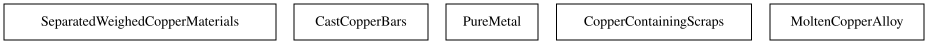

In [146]:
dot_graph = g.to_graphviz_cluster(name="CombinedProcess", rankdir="TD", collapsed=True)
dot_graph